# Logistic Regression for Fake Review Detection

This notebook implements an optimized **Logistic Regression** model to classify reviews as either **Real** (Original Reviews) or **Fake** (Computer-Generated). 

### Objectives:
1. Load preprocessed TF-IDF features.
2. Perform hyperparameter tuning using `GridSearchCV` to find the most effective model configuration.
3. Evaluate model performance using accuracy, classification reports, and ROC-AUC metrics.
4. Visualize results via Confusion Matrix and ROC Curve.
5. Identify and visualize key features (keywords) that the model uses to distinguish between classes.


## 1. Imports and Loading Data

We start by importing the necessary libraries and loading the TF-IDF features (`X`) and labels (`y`). We also define paths for model persistence.


In [5]:
import os
import joblib
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc

# Set seed for reproducibility
RANDOM_STATE = 42

# Paths
DATA_DIR = "../data/processed"
X_path = os.path.join(DATA_DIR, "X_tfidf.pkl")
y_path = os.path.join(DATA_DIR, "y.pkl")
MODEL_PATH = os.path.join(DATA_DIR, "logreg_model.pkl")

print("Loading TF-IDF features and labels...")
if os.path.exists(X_path) and os.path.exists(y_path):
    X = joblib.load(X_path)
    y = joblib.load(y_path)
    print(f"Features shape: {X.shape}")
    print(f"Labels shape: {y.shape}")
else:
    print("Error: Data files not found. Please run the TF-IDF notebook first.")


Loading TF-IDF features and labels...
Features shape: (40432, 15000)
Labels shape: (40432,)


## 2. Train/Test Split

We use a standard 80/20 split. `stratify=y` is crucial to maintain class balance in both training and testing sets, although our dataset is already balanced.


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
print(f"Training samples: {X_train.shape[0]}, Testing samples: {X_test.shape[0]}")


Training samples: 32345, Testing samples: 8087


## 3. Hyperparameter Optimization

We use `GridSearchCV` to explore a range of regularization strengths (`C`) and solvers. This ensures we aren't just using default settings but are finding the optimal configuration for this specific dataset.


In [7]:
param_grid = {
    'C': [0.1, 1, 10, 100],
    'solver': ['liblinear', 'lbfgs'],
    'max_iter': [1000]
}

print("Starting Hyperparameter Tuning with GridSearchCV...")
grid_search = GridSearchCV(
    LogisticRegression(random_state=RANDOM_STATE),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best CV Score: {grid_search.best_score_:.4f}")

best_log_reg = grid_search.best_estimator_


Starting Hyperparameter Tuning with GridSearchCV...
Fitting 5 folds for each of 8 candidates, totalling 40 fits
Best Parameters: {'C': 10, 'max_iter': 1000, 'solver': 'liblinear'}
Best CV Score: 0.9058


## 4. Comprehensive Evaluation

We evaluate the model on the unseen test set and visualize the performance through a Confusion Matrix and an ROC Curve.



Test Set Accuracy: 0.9106

Classification Report:
              precision    recall  f1-score   support

   Real (OR)       0.91      0.91      0.91      4044
   Fake (CG)       0.91      0.91      0.91      4043

    accuracy                           0.91      8087
   macro avg       0.91      0.91      0.91      8087
weighted avg       0.91      0.91      0.91      8087



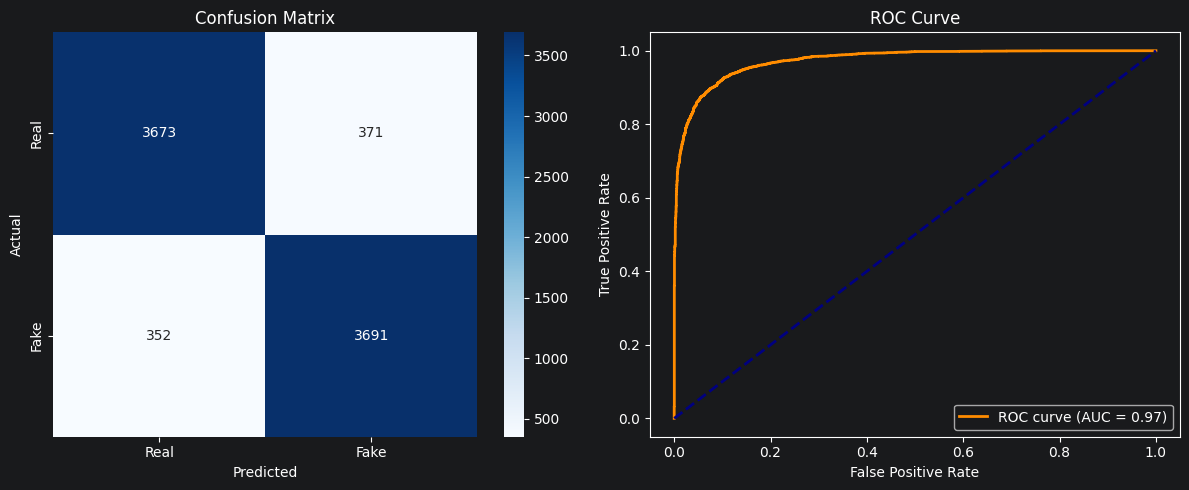

In [8]:
y_pred = best_log_reg.predict(X_test)
y_prob = best_log_reg.predict_proba(X_test)[:, 1]
accuracy = accuracy_score(y_test, y_pred)

print(f"\nTest Set Accuracy: {accuracy:.4f}\n")
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=["Real (OR)", "Fake (CG)"]))

# Visualizations
plt.figure(figsize=(12, 5))

# 1. Confusion Matrix
plt.subplot(1, 2, 1)
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=["Real", "Fake"], yticklabels=["Real", "Fake"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

# 2. ROC Curve
plt.subplot(1, 2, 2)
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc="lower right")

plt.tight_layout()
plt.show()


## 5. Model Persistence

Saving the optimized model and the best parameters for future inference (e.g., in a GUI application).


In [9]:
joblib.dump(best_log_reg, MODEL_PATH)
print(f"Optimized model saved to: {MODEL_PATH}")


Optimized model saved to: ../data/processed\logreg_model.pkl


## 6. Analyzing Top Features

Finally, we inspect the model coefficients to understand which words most strongly indicate a fake review versus a real one.


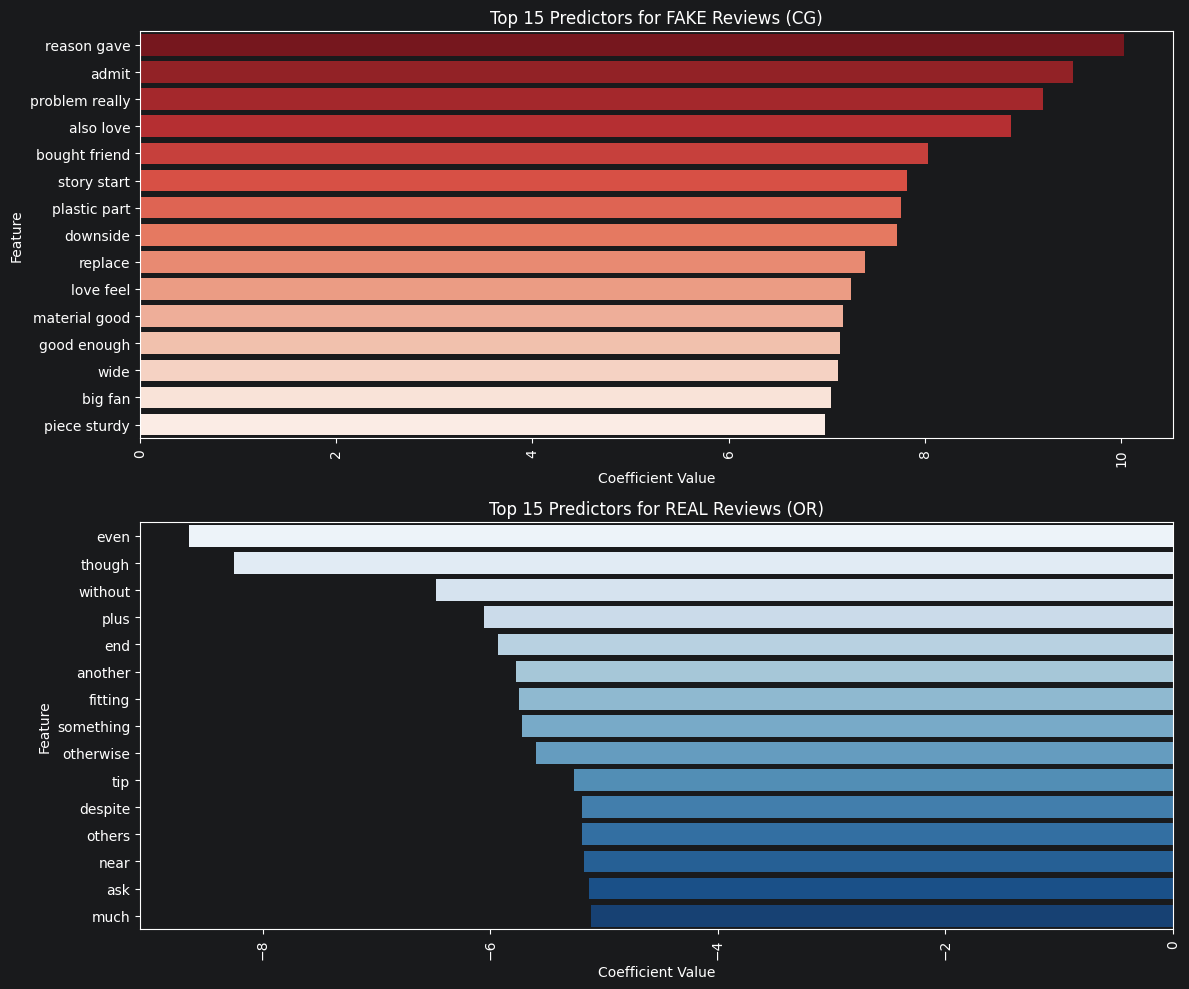

In [17]:
vectorizer_path = os.path.join(DATA_DIR, "tfidf_vectorizer.pkl")
if os.path.exists(vectorizer_path):
    vectorizer = joblib.load(vectorizer_path)
    feature_names = vectorizer.get_feature_names_out()
    coef = best_log_reg.coef_[0]

    # Get top indices
    top_fake_idx = np.argsort(coef)[-15:][::-1]
    top_real_idx = np.argsort(coef)[:15]

    # Plotting
    plt.figure(figsize=(12, 10))

    plt.subplot(2, 1, 1)
    sns.barplot(x=coef[top_fake_idx], y=feature_names[top_fake_idx], palette='Reds_r', hue=feature_names[top_fake_idx], legend=False)
    plt.ylabel("Feature")
    plt.xticks(rotation=90)
    plt.title("Top 15 Predictors for FAKE Reviews (CG)")
    plt.xlabel("Coefficient Value")

    plt.subplot(2, 1, 2)
    sns.barplot(x=coef[top_real_idx], y=feature_names[top_real_idx], palette='Blues', hue=feature_names[top_real_idx], legend=False)
    plt.ylabel("Feature")
    plt.xticks(rotation=90)
    plt.title("Top 15 Predictors for REAL Reviews (OR)")
    plt.xlabel("Coefficient Value")

    plt.tight_layout()
    plt.show()
else:
    print("Vectorizer not found. Skipping feature analysis.")
